<a href="https://colab.research.google.com/github/REVATHIPATHI1707/Predictive_Analytics/blob/predictiveanalysis/customer_product.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Customer 17850 most frequently bought products:
 - WOOD 2 DRAWER CABINET WHITE FINISH: 20 times
 - GLASS STAR FROSTED T-LIGHT HOLDER: 19 times
 - WHITE HANGING HEART T-LIGHT HOLDER: 17 times
 - WHITE METAL LANTERN: 17 times
 - KNITTED UNION FLAG HOT WATER BOTTLE: 17 times


/tmp/ipython-input-1-574192405.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=products, palette='viridis')


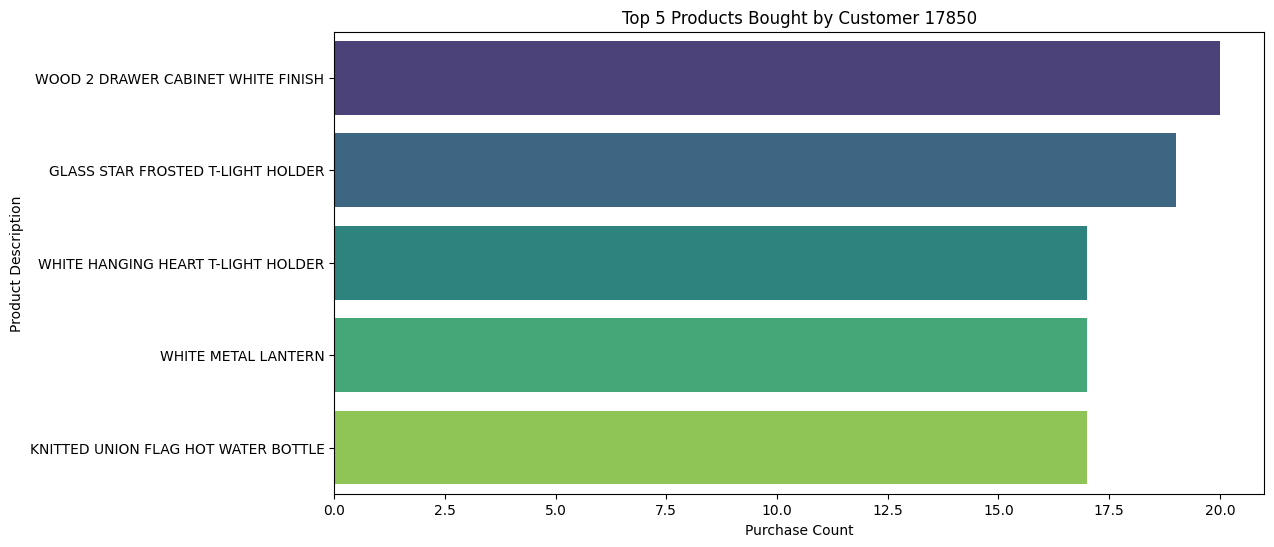


Predicted products the customer might buy next:
['WOOD 2 DRAWER CABINET WHITE FINISH', 'GLASS STAR FROSTED T-LIGHT HOLDER', 'WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'KNITTED UNION FLAG HOT WATER BOTTLE']


/tmp/ipython-input-1-574192405.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=products, palette='viridis')


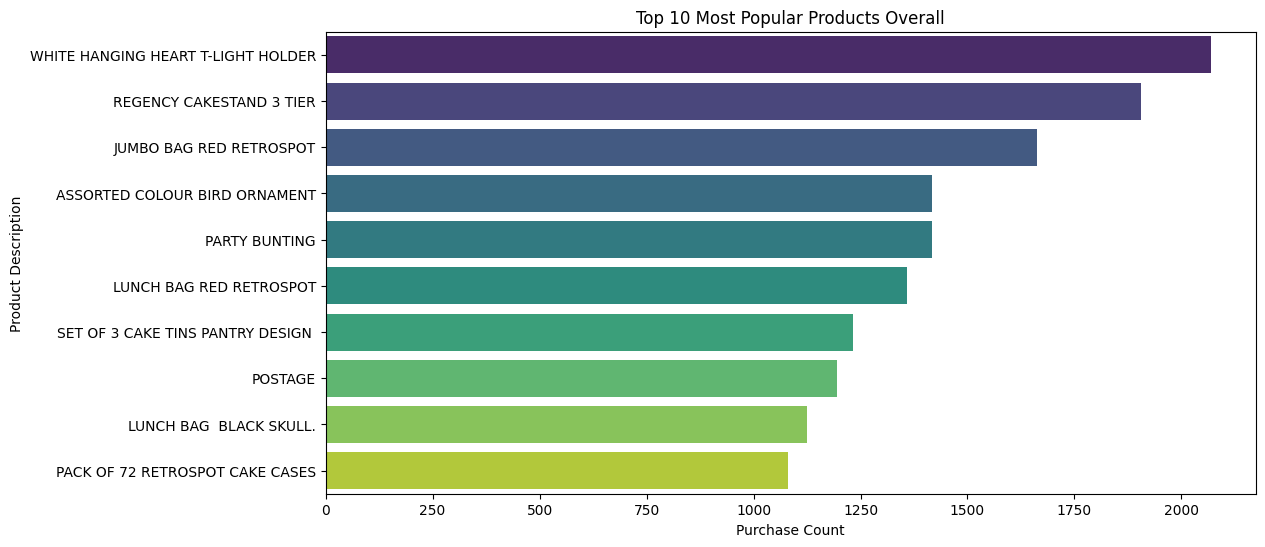

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load Excel dataset directly from UCI repo
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx'
df = pd.read_excel(url)

# Data preprocessing: Remove rows with missing CustomerID or Description
df = df.dropna(subset=['CustomerID', 'Description'])
df['CustomerID'] = df['CustomerID'].astype(int)

def plot_top_products(products_counter, title, top_n=10):
    """Plot bar chart of top N products."""
    most_common = products_counter.most_common(top_n)
    products = [x[0] for x in most_common]
    counts = [x[1] for x in most_common]

    plt.figure(figsize=(12,6))
    sns.barplot(x=counts, y=products, palette='viridis')
    plt.title(title)
    plt.xlabel('Purchase Count')
    plt.ylabel('Product Description')
    plt.show()

def predict_next_product(customer_id, df, top_n=3):
    # Get all purchases by the customer
    customer_purchases = df[df['CustomerID'] == customer_id]['Description']

    if customer_purchases.empty:
        return f"No purchase history found for CustomerID {customer_id}"

    # Count frequency of each product the customer bought
    product_counts = Counter(customer_purchases)

    print(f"Customer {customer_id} most frequently bought products:")
    for product, count in product_counts.most_common(top_n):
        print(f" - {product}: {count} times")

    # Plot customer's top products
    plot_top_products(product_counts, f"Top {top_n} Products Bought by Customer {customer_id}", top_n=top_n)

    # Predict next likely products (top_n most frequent)
    predicted_products = [product for product, count in product_counts.most_common(top_n)]
    return predicted_products

# Also plot overall top products in the dataset
def plot_overall_top_products(df, top_n=10):
    overall_counts = Counter(df['Description'])
    plot_top_products(overall_counts, f"Top {top_n} Most Popular Products Overall", top_n=top_n)

# Example usage
customer_id = 17850

predictions = predict_next_product(customer_id, df, top_n=5)

print("\nPredicted products the customer might buy next:")
print(predictions)

# Plot overall top products
plot_overall_top_products(df, top_n=10)
